In [3]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print("Setup Complete ")

/kaggle/input/omics-publication-data/OMICS PUBLICATION DATA .csv
Setup Complete 


In [5]:
ngs_filepath = "/kaggle/input/omics-publication-data/OMICS PUBLICATION DATA .csv"
data = pd.read_csv(ngs_filepath, index_col= "Year",parse_dates=True)
print(data)

            Genomics  Proteomics  Transcriptomics  Multi-omics
Year                                                          
2020-01-01      5948         903              900          103
2021-01-01      6509        1049             1024          219
2022-01-01      5300         881              851          265
2023-01-01      4906         852              848          289
2024-01-01      5073         969              845          350
2025-07-01      2930         564              577          324


In [7]:
df = pd.read_csv("/kaggle/input/omics-publication-data/OMICS PUBLICATION DATA .csv")
# Convert 'Year' to year-only integers
df['Year'] = pd.to_datetime(df['Year']).dt.year
# Reshape from wide to long
df_long = pd.melt(df, id_vars=['Year'], 
                  var_name='Omic_Type', 
                  value_name='Publications')
print(df_long)

    Year        Omic_Type  Publications
0   2020         Genomics          5948
1   2021         Genomics          6509
2   2022         Genomics          5300
3   2023         Genomics          4906
4   2024         Genomics          5073
5   2025         Genomics          2930
6   2020       Proteomics           903
7   2021       Proteomics          1049
8   2022       Proteomics           881
9   2023       Proteomics           852
10  2024       Proteomics           969
11  2025       Proteomics           564
12  2020  Transcriptomics           900
13  2021  Transcriptomics          1024
14  2022  Transcriptomics           851
15  2023  Transcriptomics           848
16  2024  Transcriptomics           845
17  2025  Transcriptomics           577
18  2020      Multi-omics           103
19  2021      Multi-omics           219
20  2022      Multi-omics           265
21  2023      Multi-omics           289
22  2024      Multi-omics           350
23  2025      Multi-omics           324


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

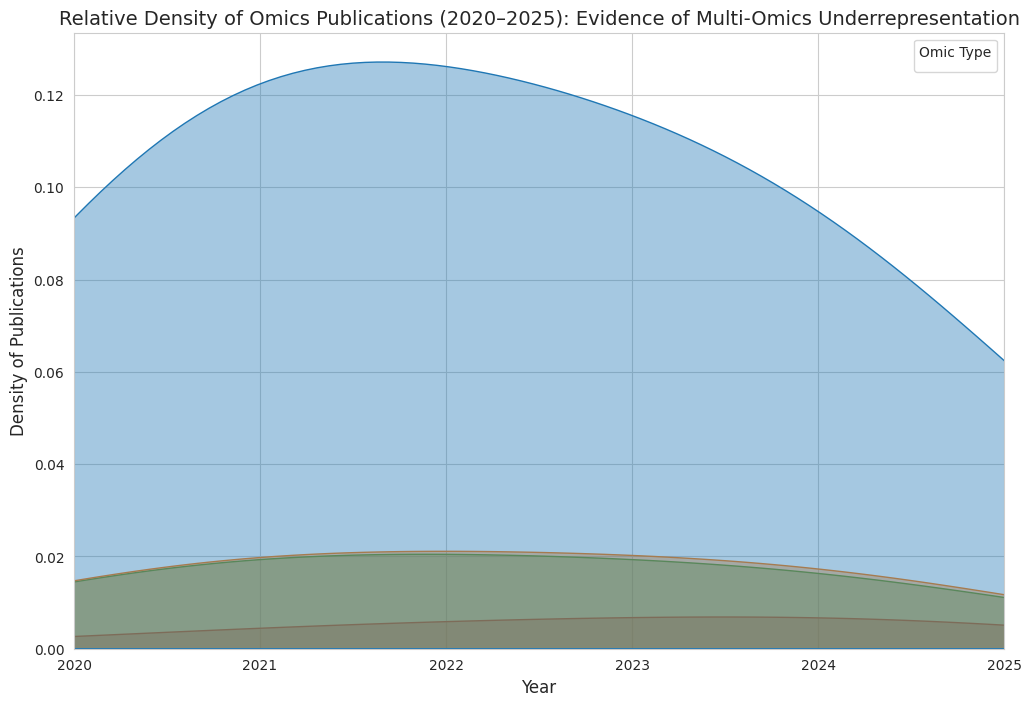

In [13]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=df_long, x='Year', weights='Publications', hue='Omic_Type', fill=True, alpha=0.4)
plt.title("Relative Density of Omics Publications (2020–2025): Evidence of Multi-Omics Underrepresentation", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Density of Publications", fontsize=12)
plt.xlim(2020, 2025)  # Limit to your actual data range
plt.xticks(range(2020, 2026))  # Tighter year ticks for clarity
plt.legend(title="Omic Type")
sns.set_style("whitegrid")
plt.legend(title="Omic Type")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


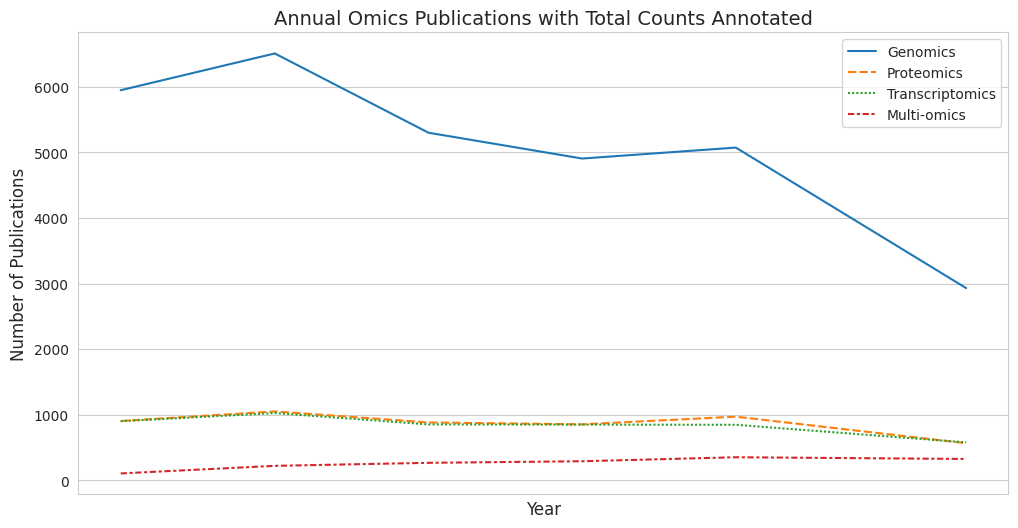

In [12]:
plt.figure(figsize=(12,6))
plt.title("Annual Omics Publications with Total Counts Annotated", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.xticks(range(2020, 2026))
sns.set_style("whitegrid")
sns.lineplot(data=data)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

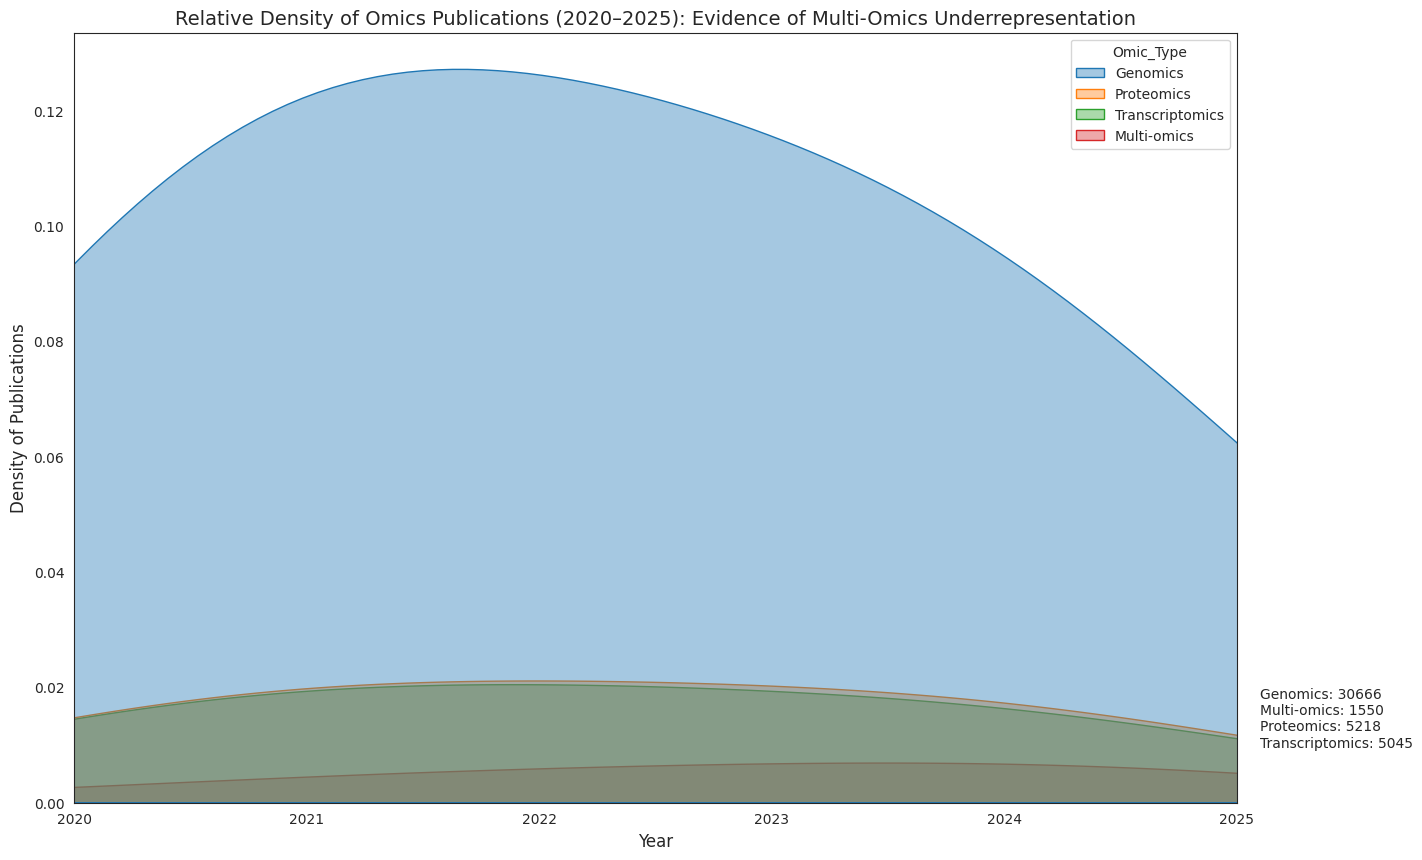

In [15]:
# Load Data
df = pd.read_csv("/kaggle/input/omics-publication-data/OMICS PUBLICATION DATA .csv")
df['Year'] = pd.to_datetime(df['Year']).dt.year
# Reshape to Long Format
df_long = pd.melt(df, id_vars=['Year'],
                  var_name='Omic_Type',
                  value_name='Publications')
# Calculate Total Publications per Omic Type
totals = df_long.groupby("Omic_Type")["Publications"].sum()
# KDE Plot
plt.figure(figsize=(15, 10))
sns.kdeplot(data=df_long, x='Year', weights='Publications', hue='Omic_Type', fill=True, alpha=0.4)
plt.title("Relative Density of Omics Publications (2020–2025): Evidence of Multi-Omics Underrepresentation", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Density of Publications", fontsize=12)
plt.xlim(2020, 2025)
plt.xticks(range(2020, 2026))
sns.set_style("white")
# ✅ Add Total Publications as Text Box Inside Plot
text = "\n".join([f"{omic}: {total}" for omic, total in totals.items()])
plt.text(2025.1, 0.02, text, fontsize=10, va='top', ha='left')
plt.show()

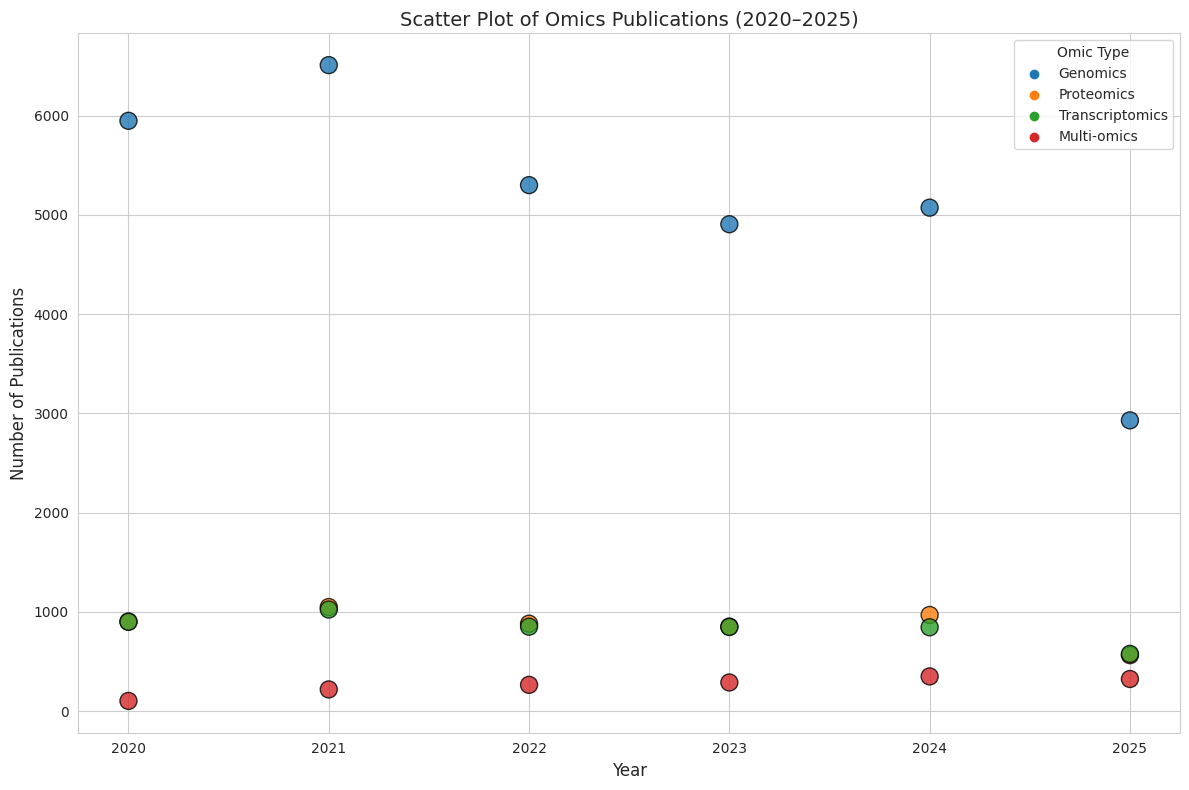

In [17]:
# Load Data
df = pd.read_csv("/kaggle/input/omics-publication-data/OMICS PUBLICATION DATA .csv")
df['Year'] = pd.to_datetime(df['Year']).dt.year

# Reshape to Long Format
df_long = pd.melt(df, id_vars=['Year'],
                  var_name='Omic_Type',
                  value_name='Publications')

# Scatter Plot for Multiple Omic Types
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_long, x='Year', y='Publications', hue='Omic_Type', s=150, alpha=0.8, edgecolor='black')

plt.title("Scatter Plot of Omics Publications (2020–2025)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.xticks(range(2020, 2026))
sns.set_style("whitegrid")
plt.legend(title="Omic Type")
plt.tight_layout()
plt.show()